DATASET SHAPE
(4269, 13)

FIRST 5 ROWS
   loan_id  no_of_dependents      education  self_employed   income_annum  \
0        1                 2       Graduate             No        9600000   
1        2                 0   Not Graduate            Yes        4100000   
2        3                 3       Graduate             No        9100000   
3        4                 3       Graduate             No        8200000   
4        5                 5   Not Graduate            Yes        9800000   

    loan_amount   loan_term   cibil_score   residential_assets_value  \
0      29900000          12           778                    2400000   
1      12200000           8           417                    2700000   
2      29700000          20           506                    7100000   
3      30700000           8           467                   18200000   
4      24200000          20           382                   12400000   

    commercial_assets_value   luxury_assets_value   bank_asset_va

/tmp/ipykernel_3037/848107714.py:71: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_3037/848107714.py:69: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

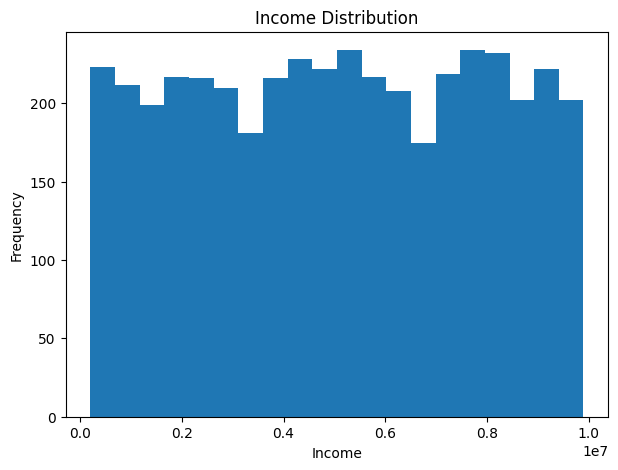

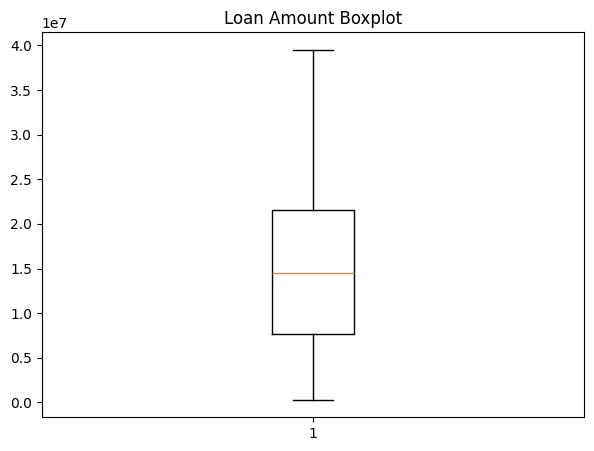

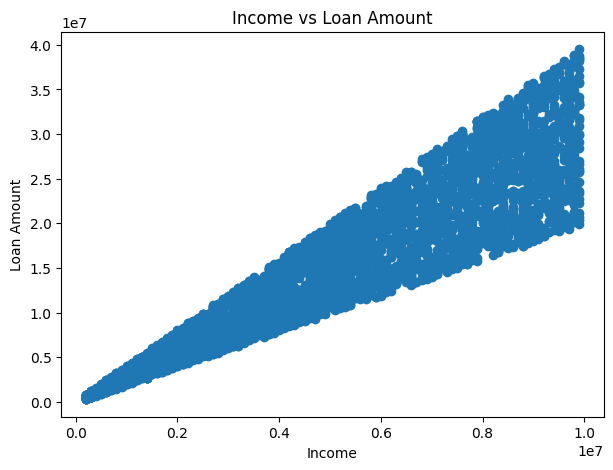

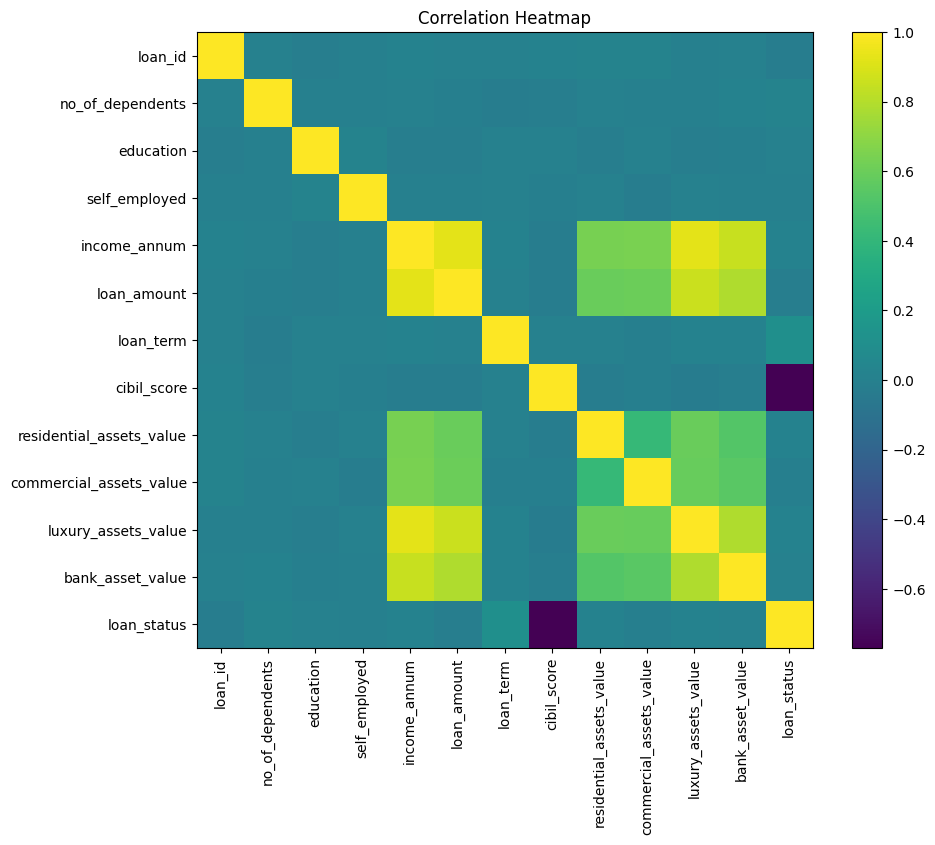


Logistic Regression
Accuracy : 0.9227
Precision: 0.9159
Recall   : 0.8762
F1 Score : 0.8956
ROC AUC  : 0.9745

Confusion Matrix
[[505  26]
 [ 40 283]]

Random Forest
Accuracy : 0.9824
Precision: 0.9904
Recall   : 0.9628
F1 Score : 0.9765
ROC AUC  : 0.9978

Confusion Matrix
[[528   3]
 [ 12 311]]

XGBoost
Accuracy : 0.9836
Precision: 0.9874
Recall   : 0.969
F1 Score : 0.9781
ROC AUC  : 0.9986

Confusion Matrix
[[527   4]
 [ 10 313]]


MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0  Logistic Regression  0.922717   0.915858  0.876161  0.895570  0.974486
1        Random Forest  0.982436   0.990446  0.962848  0.976452  0.997761
2              XGBoost  0.983607   0.987382  0.969040  0.978125  0.998560

BEST MODEL
     Model  Accuracy  Precision   Recall  F1 Score  ROC AUC
2  XGBoost  0.983607   0.987382  0.96904  0.978125  0.99856


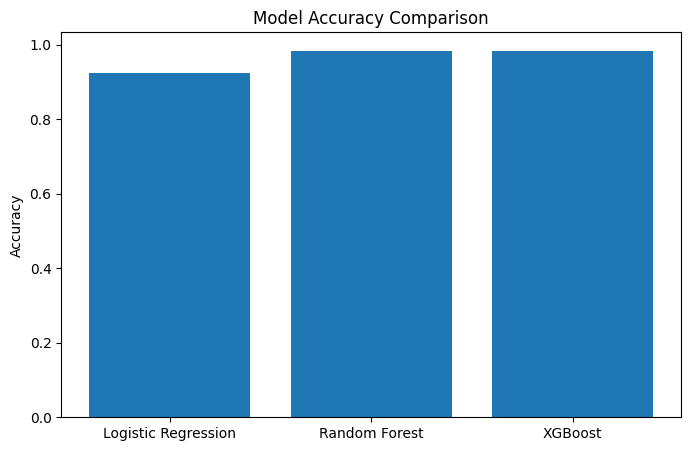

In [2]:
# ============================================================
# LOAN APPROVAL PREDICTION SYSTEM
# AIML SUMMER INTERNSHIP CAPSTONE PROJECT
# ============================================================

# ============================================================
# PHASE 1 : IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# ============================================================
# PHASE 2 : DATA COLLECTION
# Load Dataset
# ============================================================

df = pd.read_csv("loan_approval_dataset.csv")

print("="*60)
print("DATASET SHAPE")
print(df.shape)

print("\nFIRST 5 ROWS")
print(df.head())

# ============================================================
# PHASE 3 : DATA PREPROCESSING
# ============================================================

# Remove unwanted spaces from column names

df.columns = df.columns.str.strip()

print("\nColumn Names")
print(df.columns)

# ------------------------------------------------------------
# Missing Values
# ------------------------------------------------------------

print("\nMissing Values")
print(df.isnull().sum())

# Fill missing values if present

for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

# ------------------------------------------------------------
# Duplicate Removal
# ------------------------------------------------------------

print("\nDuplicates Before :", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Duplicates After :", df.duplicated().sum())

# ------------------------------------------------------------
# Outlier Treatment
# Using IQR Method
# ------------------------------------------------------------

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

# ------------------------------------------------------------
# Encode Categorical Features
# ------------------------------------------------------------

encoder = LabelEncoder()

categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

# ============================================================
# PHASE 4 : EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

# ------------------------------------------------------------
# Univariate Analysis
# Histogram
# ------------------------------------------------------------

plt.figure(figsize=(7,5))
plt.hist(df["income_annum"], bins=20)
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

# ------------------------------------------------------------
# Boxplot
# ------------------------------------------------------------

plt.figure(figsize=(7,5))
plt.boxplot(df["loan_amount"])
plt.title("Loan Amount Boxplot")
plt.show()

# ------------------------------------------------------------
# Bivariate Analysis
# Scatter Plot
# ------------------------------------------------------------

plt.figure(figsize=(7,5))
plt.scatter(df["income_annum"], df["loan_amount"])

plt.xlabel("Income")
plt.ylabel("Loan Amount")
plt.title("Income vs Loan Amount")

plt.show()

# ------------------------------------------------------------
# Correlation Analysis
# Heatmap
# ------------------------------------------------------------

corr_matrix = df.corr()

plt.figure(figsize=(10,8))

plt.imshow(corr_matrix)

plt.colorbar()

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title("Correlation Heatmap")

plt.show()

# ============================================================
# PHASE 5 : FEATURE ENGINEERING
# ============================================================

# Create Total Assets Feature

df["total_assets"] = (
    df["residential_assets_value"]
    + df["commercial_assets_value"]
    + df["luxury_assets_value"]
    + df["bank_asset_value"]
)

# Remove loan_id because it has no predictive power

df.drop("loan_id", axis=1, inplace=True)

# ============================================================
# Feature Selection
# ============================================================

X = df.drop("loan_status", axis=1)

y = df["loan_status"]

# ============================================================
# Feature Scaling
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ============================================================
# Train Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ============================================================
# PHASE 6 : MODEL BUILDING
# ============================================================

models = {

    "Logistic Regression":
    LogisticRegression(max_iter=1000),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "XGBoost":
    XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        eval_metric='logloss'
    )
}

# ============================================================
# PHASE 7 : MODEL EVALUATION
# ============================================================

results = []

for name, model in models.items():

    print("\n" + "="*60)
    print(name)
    print("="*60)

    # Train Model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities for ROC-AUC
    y_prob = model.predict_proba(X_test)[:,1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

    print("Accuracy :", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1 Score :", round(f1,4))
    print("ROC AUC  :", round(roc_auc,4))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])

# ============================================================
# MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
)

print("\n")
print("="*60)
print("MODEL COMPARISON")
print("="*60)

print(results_df)

# ============================================================
# BEST MODEL
# ============================================================

best_model = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\nBEST MODEL")
print(best_model.head(1))

# ============================================================
# VISUALIZATION OF MODEL ACCURACY
# ============================================================

plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

XGBoost Model Trained Successfully

Feature Importance Ranking
                     Feature  Importance
6                cibil_score    0.679883
5                  loan_term    0.198055
4                loan_amount    0.025827
3               income_annum    0.022757
10          bank_asset_value    0.012222
9        luxury_assets_value    0.010914
7   residential_assets_value    0.010729
2              self_employed    0.010493
0           no_of_dependents    0.009565
8    commercial_assets_value    0.008570
11              total_assets    0.005836
1                  education    0.005150


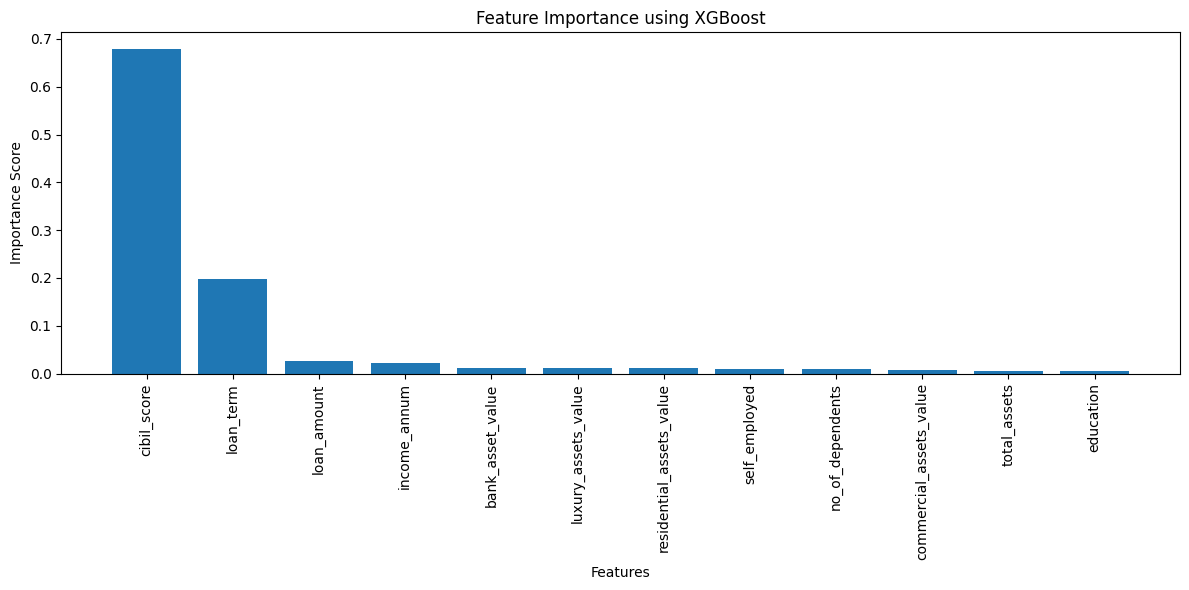


Model Saved Successfully
Scaler Saved Successfully

Files Present in Current Directory:
['.config', 'loan_approval_xgboost.pkl', 'loan_approval_dataset.csv', 'scaler.pkl', 'sample_data']

Saved Model Loaded Successfully

Final Selected Model : XGBoost
Accuracy Achieved    : 98.36%
Model Ready For Deployment


In [3]:
# ============================================================
# FEATURE IMPORTANCE ANALYSIS + MODEL SAVING
# ============================================================

# Import library for saving the model
import joblib

# ============================================================
# STEP 1: TRAIN THE BEST MODEL AGAIN
# ============================================================
# Since XGBoost gave the highest accuracy (98.36%),
# we select it as the final model.

best_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)

# Train the model on training data
best_model.fit(X_train, y_train)

print("XGBoost Model Trained Successfully")


# ============================================================
# STEP 2: FEATURE IMPORTANCE ANALYSIS
# ============================================================
# Feature importance tells us which features contribute
# the most in loan approval prediction.

importance = best_model.feature_importances_

# Create a DataFrame for better visualization
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

# Sort features from most important to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display feature importance table
print("\nFeature Importance Ranking")
print(feature_importance)


# ============================================================
# STEP 3: VISUALIZE FEATURE IMPORTANCE
# ============================================================
# Create a bar graph to show the importance of each feature

plt.figure(figsize=(12,6))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance using XGBoost")

plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()


# ============================================================
# STEP 4: SAVE THE TRAINED MODEL
# ============================================================
# Saving the model allows us to use it later in
# Streamlit deployment without retraining.

joblib.dump(
    best_model,
    "loan_approval_xgboost.pkl"
)

print("\nModel Saved Successfully")


# ============================================================
# STEP 5: SAVE THE SCALER
# ============================================================
# The same scaler used during training must also be
# used during prediction in the deployed application.

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Scaler Saved Successfully")


# ============================================================
# STEP 6: VERIFY SAVED FILES
# ============================================================
# Check whether the files were saved successfully.

import os

print("\nFiles Present in Current Directory:")
print(os.listdir())


# ============================================================
# STEP 7: TEST MODEL LOADING
# ============================================================
# Load the saved model to verify it was stored correctly.

loaded_model = joblib.load(
    "loan_approval_xgboost.pkl"
)

print("\nSaved Model Loaded Successfully")


# ============================================================
# PROJECT CONCLUSION
# ============================================================
print("\nFinal Selected Model : XGBoost")
print("Accuracy Achieved    : 98.36%")
print("Model Ready For Deployment")

In [4]:
# Save feature names used during training

feature_columns = X.columns.tolist()

print(feature_columns)

['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'total_assets']


In [5]:
import joblib

loaded_model = joblib.load(
    "loan_approval_xgboost.pkl"
)

print(type(loaded_model))

<class 'xgboost.sklearn.XGBClassifier'>
